<a href="https://colab.research.google.com/github/NoDanCoder/AirBnB_clone/blob/master/Semana7/IntegracionMonteCarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
  return x**2

In [3]:
def Integrar(f, a, b, N=10):

  x = np.random.uniform(a,b,size=N)
  # Metemos la funcion aca
  funcion = f(x)

  Promedio = np.mean(funcion)

  Integral = (b-a)*Promedio
  return Integral

In [4]:
Integrar(f,2,3,N=10000)

np.float64(6.332359019268486)

In [5]:
19/3

6.333333333333333

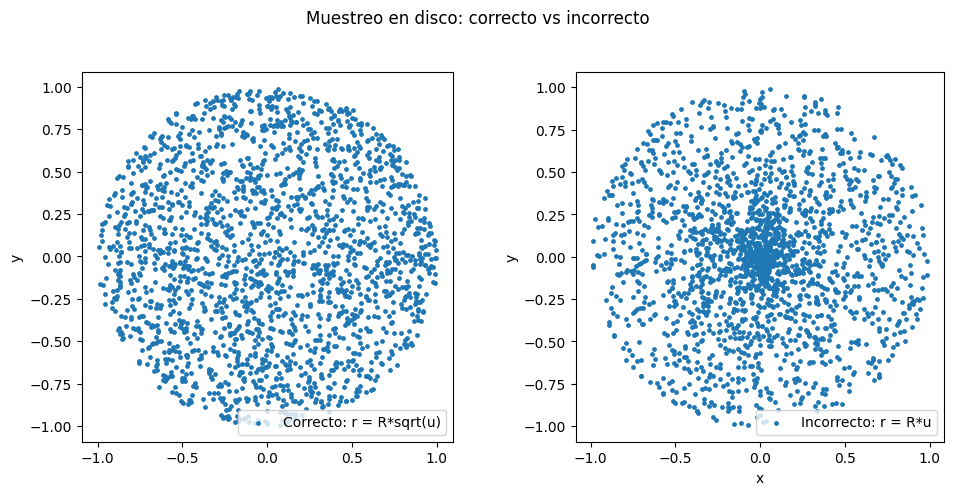

In [6]:
def disco_sampling_comparacion(R=1.0, N=100):


    # -------------------------
    # CORRECTO: uniforme en área
    # -------------------------
    u = np.random.rand(N)
    v = np.random.rand(N)
    r_ok = R * np.sqrt(u)
    th_ok = 2*np.pi * v
    x_ok = r_ok * np.cos(th_ok)
    y_ok = r_ok * np.sin(th_ok)

    # -------------------------
    # INCORRECTO: r uniforme (sesgo al centro)
    # -------------------------
    u2 = np.random.rand(N)
    v2 = np.random.rand(N)
    r_bad = R * u2
    th_bad = 2*np.pi * v2
    x_bad = r_bad * np.cos(th_bad)
    y_bad = r_bad * np.sin(th_bad)


    fig, ax = plt.subplots(1, 2, figsize=(10,5))
    ax[0].scatter(x_ok,  y_ok,  s=6, label="Correcto: r = R*sqrt(u)")
    ax[1].scatter(x_bad, y_bad, s=6, label="Incorrecto: r = R*u")
    ax[0].set_aspect('equal', 'box')
    ax[1].set_aspect('equal', 'box')
    fig.suptitle("Muestreo en disco: correcto vs incorrecto")
    ax[0].set_ylabel("y")
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("y")
    ax[0].legend()
    ax[1].legend()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

if __name__ == "__main__":
    disco_sampling_comparacion(R=1, N=2000)

In [10]:
def Momento(R=1, N = 10000):

  u = np.random.uniform(0,1,N)
  v = np.random.uniform(0,1,N)

  r = R * np.sqrt(u)
  th = 2*np.pi * v

  x = r * np.cos(th)
  y = r * np.sin(th)

  # MOmento de inercia
  f = x**2 + y**2

  I = np.pi*R**2 * np.mean(f)

  return I

In [11]:
Momento(1)

np.float64(1.5674031518942622)

In [31]:
import numpy as np

n = 100_000
F = np.array([0])

for x in range(n):
  x = np.random.uniform(0, 1, 8)
  F = np.append(F, np.sum(x)**2)

I = (2**-7)*np.mean(F)

print(f"estimacion: {I}")
print(f"exacto:     {25/192}")

estimacion: 0.13032043101788812
exacto:     0.13020833333333334


In [34]:
def Momento_esfera(R=1, N=100_000):

  u = np.random.uniform(0, 1, N)
  v = np.random.uniform(0, 1, N)
  w = np.random.uniform(0, 1, N)

  r = R * u**(1/3)
  th = np.arccos(1 - 2*v)
  ph = 2*np.pi * w

  x = r * np.sin(th) * np.cos(ph)
  y = r * np.sin(th) * np.sin(ph)

  f = x**2 + y**2

  I = np.mean(f)

  return I

print(f"estimacion: {Momento_esfera()}")
print(f"exacto:     {2/5}")

estimacion: 0.4003429861213068
exacto:     0.4
